In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use('ggplot')

df_raw = pd.read_csv('Data/Healthcare_dataset.csv')

df_raw

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [8]:
df_raw.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [9]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 12.3 MB


In [10]:
df_raw['Doctor'].unique()

<ArrowStringArray>
[   'Matthew Smith',  'Samantha Davies', 'Tiffany Mitchell',
      'Kevin Wells',   'Kathleen Hanna',    'Taylor Newton',
      'Kelly Olson',   'Suzanne Thomas',  'Daniel Ferguson',
      'Heather Day',
 ...
      'Brian Adams',    'Daniel Bryant',    'Paul Sandoval',
       'Jose Davis',       'Cody Smith',  'Shannon Morales',
   'Arthur Fleming',   'Deborah Sutton',    'Mary Bartlett',
         'Alec May']
Length: 40341, dtype: str

In [12]:
df_raw['Insurance Provider'].unique()

<ArrowStringArray>
['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna']
Length: 5, dtype: str

In [13]:
df_raw['Hospital'].unique()

<ArrowStringArray>
[                 'Sons and Miller',                          'Kim Inc',
                         'Cook PLC',       'Hernandez Rogers and Vang,',
                      'White-White',                   'Nunez-Humphrey',
                  'Group Middleton',      'Powell Robinson and Valdez,',
                    'Sons Rich and',                   'Padilla-Walker',
 ...
 'Livingston Jennings and Griffin,',           'Green and Kelly, Kline',
                   'Miller-Robbins',      'Cisneros and Smith, Johnson',
      'Rodriguez Wilcox, and Chase',    'Buchanan Wheeler and Roberts,',
                       'LLC Conner',         'Guzman Jones and Graves,',
     'and Williams, Brown Mckenzie',      'Moreno Murphy, Griffith and']
Length: 39876, dtype: str

In [14]:
df = df_raw.drop(columns=['Name', 'Doctor', 'Hospital'])

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 55500 non-null  int64  
 1   Gender              55500 non-null  str    
 2   Blood Type          55500 non-null  str    
 3   Medical Condition   55500 non-null  str    
 4   Date of Admission   55500 non-null  str    
 5   Insurance Provider  55500 non-null  str    
 6   Billing Amount      55500 non-null  float64
 7   Room Number         55500 non-null  int64  
 8   Admission Type      55500 non-null  str    
 9   Discharge Date      55500 non-null  str    
 10  Medication          55500 non-null  str    
 11  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 8.7 MB


In [20]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Day Admitted'] = (df['Discharge Date'] - df['Date of Admission']).dt.days


<Axes: >

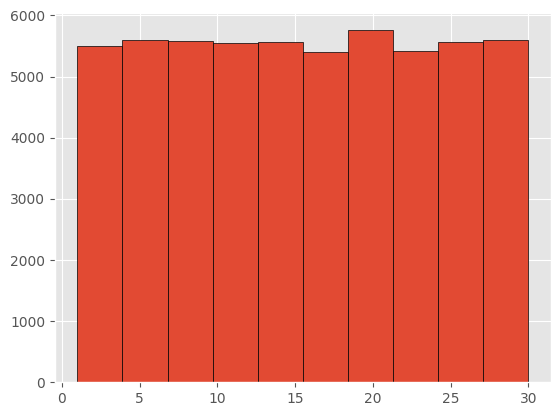

In [23]:
df['Day Admitted'].hist(edgecolor = 'black')

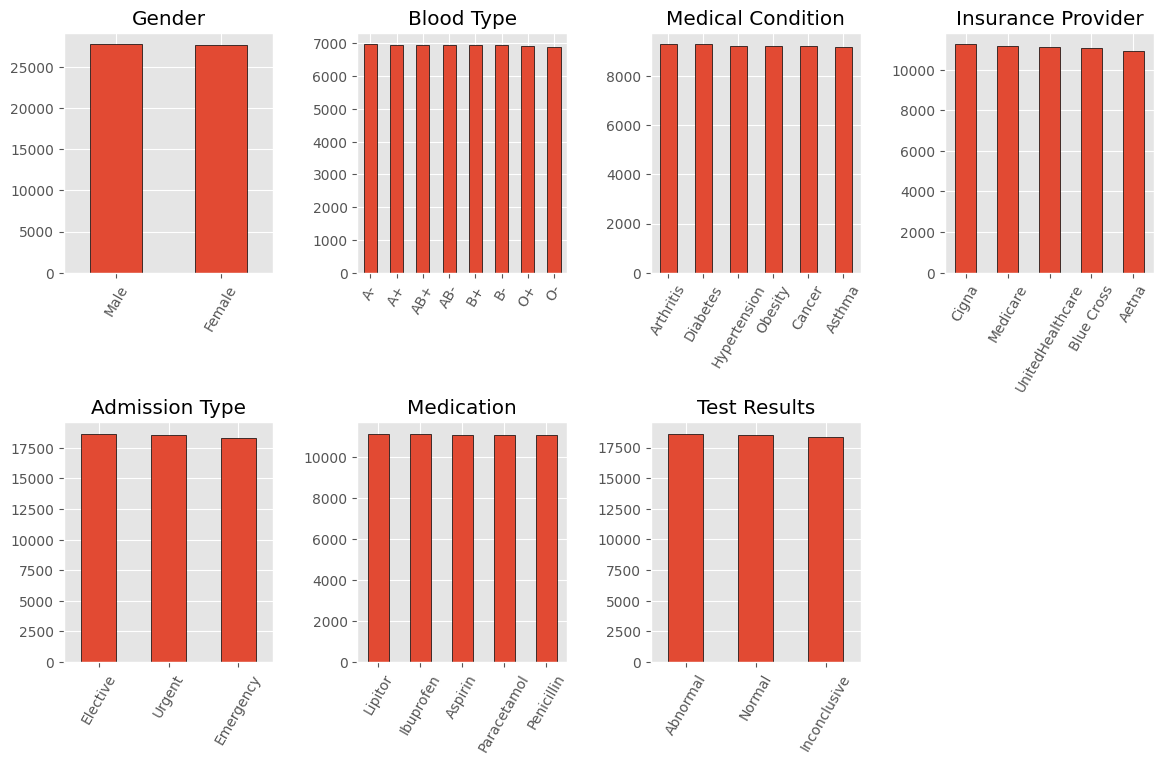

In [43]:
cat_feat = ['Gender', 'Blood Type', 'Medical Condition', 
            'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']

col = 4
row = (len(cat_feat) + col - 1) // col  # fix layout

plt.figure(figsize=(12, 8))

for count, feat in enumerate(cat_feat):
    plt.subplot(row, col, count + 1)
    
    df[feat].value_counts().plot(kind='bar', edgecolor='black')
    
    plt.xticks(rotation=60)
    plt.xlabel("")
    plt.title(feat)

plt.tight_layout(pad=2)
plt.show()

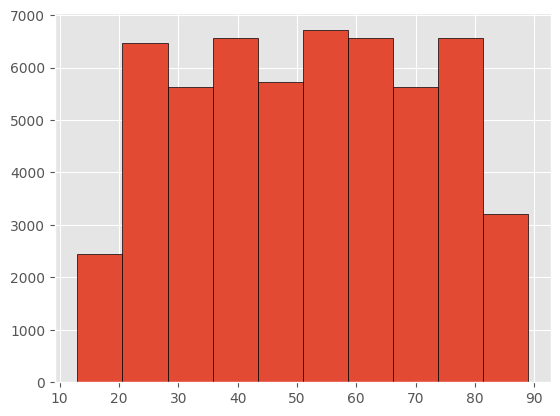

In [49]:
df['Age'].hist(edgecolor = 'black')
plt.show()

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Age                 55500 non-null  int64         
 1   Gender              55500 non-null  str           
 2   Blood Type          55500 non-null  str           
 3   Medical Condition   55500 non-null  str           
 4   Date of Admission   55500 non-null  datetime64[us]
 5   Insurance Provider  55500 non-null  str           
 6   Billing Amount      55500 non-null  float64       
 7   Room Number         55500 non-null  int64         
 8   Admission Type      55500 non-null  str           
 9   Discharge Date      55500 non-null  datetime64[us]
 10  Medication          55500 non-null  str           
 11  Test Results        55500 non-null  str           
 12  Day Admitted        55500 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(3), str(7)
memory

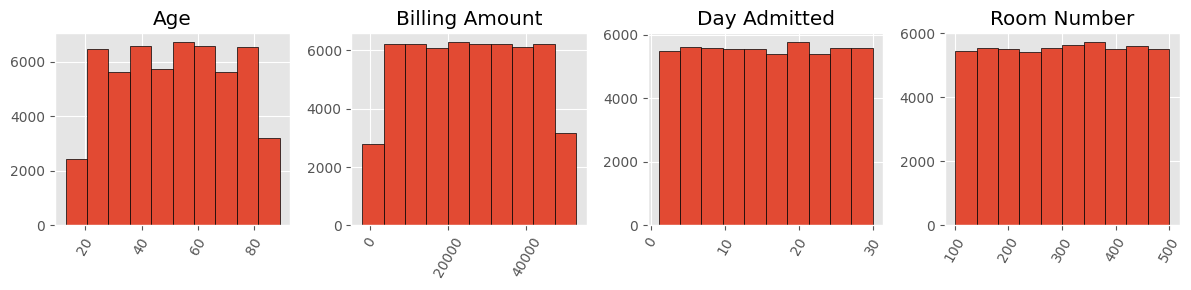

In [ ]:
num_feat = ['Age', 'Billing Amount', 'Day Admitted', 'Room Number']


col = 4
row = 1

plt.figure(figsize=(12, 3))

for count, feat in enumerate(num_feat):
    plt.subplot(row, col, count + 1)
    
    df[feat].hist( edgecolor='black')
    
    plt.xticks(rotation=60)
    plt.xlabel("")
    plt.title(feat)

plt.tight_layout()
plt.show()